# Stand-Alone Neutral Distance-Fill Proof Of Concept

This notebook inlines the direct fluvial path
`downscale_wse_raster -> downscale_costGrow_xr -> _03_dryPartials -> _distance_fill`
for `distance_fill="neutral"`.

It intentionally stops after the `_03_dryPartials` merge so the notebook stays focused on the requested path.
There are no project imports here; the workflow is written inline with simple, fast-fail code.

## 1) Imports And Hard-Coded Inputs

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
import scipy.ndimage

# Keep the notebook fully deterministic by hard-coding the test data directory.
data_dir = Path("/workspace/tests/data/bryantTechnicalNoteResolution2024")
dem_fine_fp = data_dir / "dem_04m.tif"
wse_coarse_fp = data_dir / "wse_32m.tif"
wse_fine_ref_fp = data_dir / "wse_04m.tif"

# Match the defaults used by the direct fluvial CostGrow path.
distance_fill_method = "distance_transform_cdt"
dp_coarse_pixel_max = 10
decay_frac = 0.001

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10


## 2) Load The Fine DEM, The Coarse WSE, And The Fine Reference WSE

In [2]:
# Read each raster as float64 and normalize nodata to NaN so the array math stays simple.
with rasterio.open(dem_fine_fp) as src:
    dem_fine = src.read(1, masked=True).astype("float64").filled(np.nan)
    dem_profile = src.profile.copy()
    dem_transform = src.transform
    dem_crs = src.crs
    dem_nodata = src.nodata

with rasterio.open(wse_coarse_fp) as src:
    wse_coarse = src.read(1, masked=True).astype("float64").filled(np.nan)
    wse_coarse_profile = src.profile.copy()
    wse_coarse_transform = src.transform
    wse_coarse_crs = src.crs
    wse_coarse_nodata = src.nodata

with rasterio.open(wse_fine_ref_fp) as src:
    wse_fine_ref = src.read(1, masked=True).astype("float64").filled(np.nan)
    wse_fine_ref_profile = src.profile.copy()
    wse_fine_ref_transform = src.transform
    wse_fine_ref_crs = src.crs

# Pull the scale terms once because the rest of the notebook uses them repeatedly.
pixel_size_m = abs(dem_transform.a)
downscale = dem_fine.shape[0] // wse_coarse.shape[0]

# Use shared display ranges so the WSE plots are directly comparable.
wse_vmin = min(np.nanmin(wse_coarse), np.nanmin(wse_fine_ref))
wse_vmax = max(np.nanmax(wse_coarse), np.nanmax(wse_fine_ref))

print(f"dem_fine: {dem_fine.shape} at {pixel_size_m:.1f} m")
print(f"wse_coarse: {wse_coarse.shape}")
print(f"wse_fine_ref: {wse_fine_ref.shape}")
print(f"downscale: {downscale}")


dem_fine: (1664, 3360) at 4.0 m
wse_coarse: (208, 420)
wse_fine_ref: (1664, 3360)
downscale: 8


## 3) Plot Inputs Before Running The Workflow

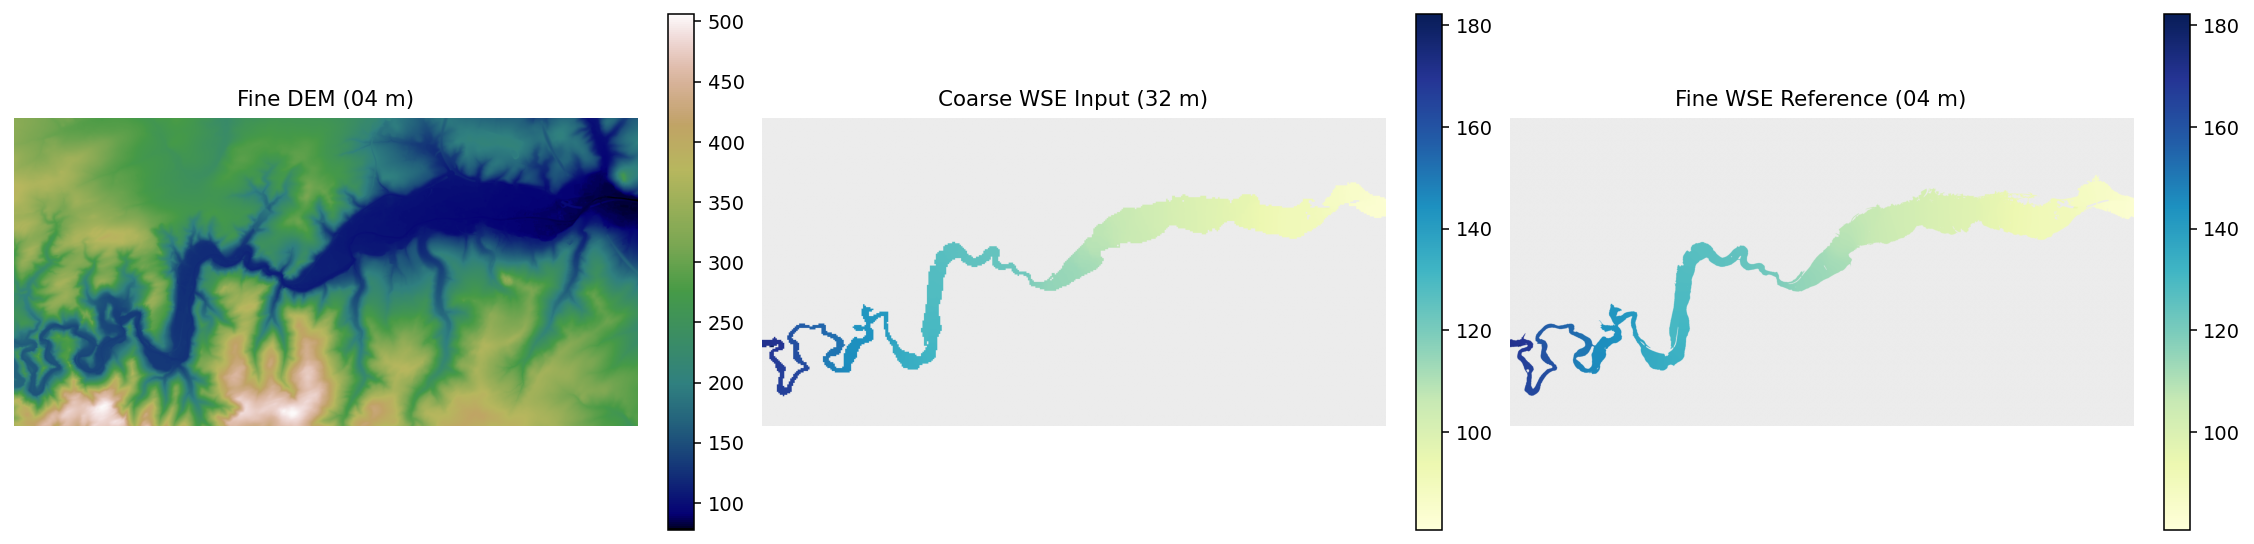

In [3]:
# Build nice colormaps once and make nodata easy to see.
dem_cmap = plt.cm.gist_earth.copy()
dem_cmap.set_bad("#f3f3f3")

wse_cmap = plt.cm.YlGnBu.copy()
wse_cmap.set_bad("#ececec")

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

im = axes[0].imshow(dem_fine, cmap=dem_cmap)
axes[0].set_title("Fine DEM (04 m)")
axes[0].set_axis_off()
fig.colorbar(im, ax=axes[0], shrink=0.75)

im = axes[1].imshow(wse_coarse, cmap=wse_cmap, vmin=wse_vmin, vmax=wse_vmax)
axes[1].set_title("Coarse WSE Input (32 m)")
axes[1].set_axis_off()
fig.colorbar(im, ax=axes[1], shrink=0.75)

im = axes[2].imshow(wse_fine_ref, cmap=wse_cmap, vmin=wse_vmin, vmax=wse_vmax)
axes[2].set_title("Fine WSE Reference (04 m)")
axes[2].set_axis_off()
fig.colorbar(im, ax=axes[2], shrink=0.75)

plt.show()


## 4) Inline The Direct Fluvial Neutral Workflow

In [4]:
workflow_start = time.time()

# ------------------------------------------------------------------
# 01_resamp
# Resample the coarse WSE directly onto the fine DEM grid with bilinear interpolation.
# ------------------------------------------------------------------
wse_fine_01_raw = np.full(dem_fine.shape, dem_nodata, dtype="float64")
reproject(
    source=wse_coarse,
    destination=wse_fine_01_raw,
    src_transform=wse_coarse_transform,
    src_crs=wse_coarse_crs,
    src_nodata=np.nan,
    dst_transform=dem_transform,
    dst_crs=dem_crs,
    dst_nodata=dem_nodata,
    resampling=Resampling.bilinear,
)
wse_fine_01 = wse_fine_01_raw.astype("float64")
wse_fine_01[wse_fine_01 == dem_nodata] = np.nan

# ------------------------------------------------------------------
# 02_wetPartials
# Keep only resampled water levels that still sit above the fine DEM.
# ------------------------------------------------------------------
wse_fine_02 = wse_fine_01.copy()
wse_fine_02[np.isnan(dem_fine) | np.isnan(wse_fine_01) | (wse_fine_01 <= dem_fine)] = np.nan

# ------------------------------------------------------------------
# 03_dryPartials distance field
# Measure distance from each dry fine cell to the nearest wet anchor cell.
# ------------------------------------------------------------------
distance_ar = scipy.ndimage.distance_transform_cdt(
    np.isnan(wse_fine_02).astype(int),
    return_indices=False,
    return_distances=True,
).astype("float64") * pixel_size_m

# Convert the fine-grid distance into coarse pixels so the growth cap matches the repo logic.
distance_coarse_pixels = distance_ar / pixel_size_m / downscale
grow_thresh = distance_coarse_pixels < dp_coarse_pixel_max

# ------------------------------------------------------------------
# _distance_fill neutral branch
# Copy the nearest wet value into each masked cell using the distance-transform indices.
# ------------------------------------------------------------------
distance_indices = scipy.ndimage.distance_transform_cdt(
    np.isnan(wse_fine_02).astype(int),
    return_indices=True,
    return_distances=False,
)
wse_filled = wse_fine_02.copy()
missing = np.isnan(wse_fine_02)
wse_filled[missing] = wse_fine_02[tuple(distance_indices[:, missing])]

# ------------------------------------------------------------------
# 03_dryPartials linear decay
# Apply the same default dry-partial decay used by downscale_costGrow_xr.
# ------------------------------------------------------------------
decay_ar = np.where(missing, distance_ar * decay_frac, 0.0)
wse_filled_decayed = wse_filled - decay_ar

# ------------------------------------------------------------------
# 03_dryPartials merge
# Only keep new water where growth is eligible and the decayed fill still clears the DEM.
# ------------------------------------------------------------------
wse_fine_03 = np.where(
    missing,
    np.where(grow_thresh & (wse_filled_decayed > dem_fine), wse_filled_decayed, np.nan),
    wse_fine_02,
)
wse_fine_03[np.isnan(dem_fine)] = np.nan

# Build a few direct diagnostics so the notebook output is easy to interpret.
wsh_fine_03 = np.where(np.isnan(wse_fine_03), np.nan, wse_fine_03 - dem_fine)
delta_to_ref = wse_fine_03 - wse_fine_ref
elapsed = time.time() - workflow_start

meta_d = {
    "downscale": int(downscale),
    "pixel_size_m": float(pixel_size_m),
    "coarse_wet_cells": int(np.isfinite(wse_coarse).sum()),
    "resampled_wet_cells": int(np.isfinite(wse_fine_01).sum()),
    "wet_partial_cells": int(np.isfinite(wse_fine_02).sum()),
    "neutral_output_cells": int(np.isfinite(wse_fine_03).sum()),
    "grown_cells": int(np.isfinite(wse_fine_03).sum() - np.isfinite(wse_fine_02).sum()),
    "runtime_seconds": round(elapsed, 3),
}

meta_d


{'downscale': 8,
 'pixel_size_m': 4.0,
 'coarse_wet_cells': 6907,
 'resampled_wet_cells': 442048,
 'wet_partial_cells': 425253,
 'neutral_output_cells': 449443,
 'grown_cells': 24190,
 'runtime_seconds': 0.463}

## 5) Plot The Neutral-Path Outputs

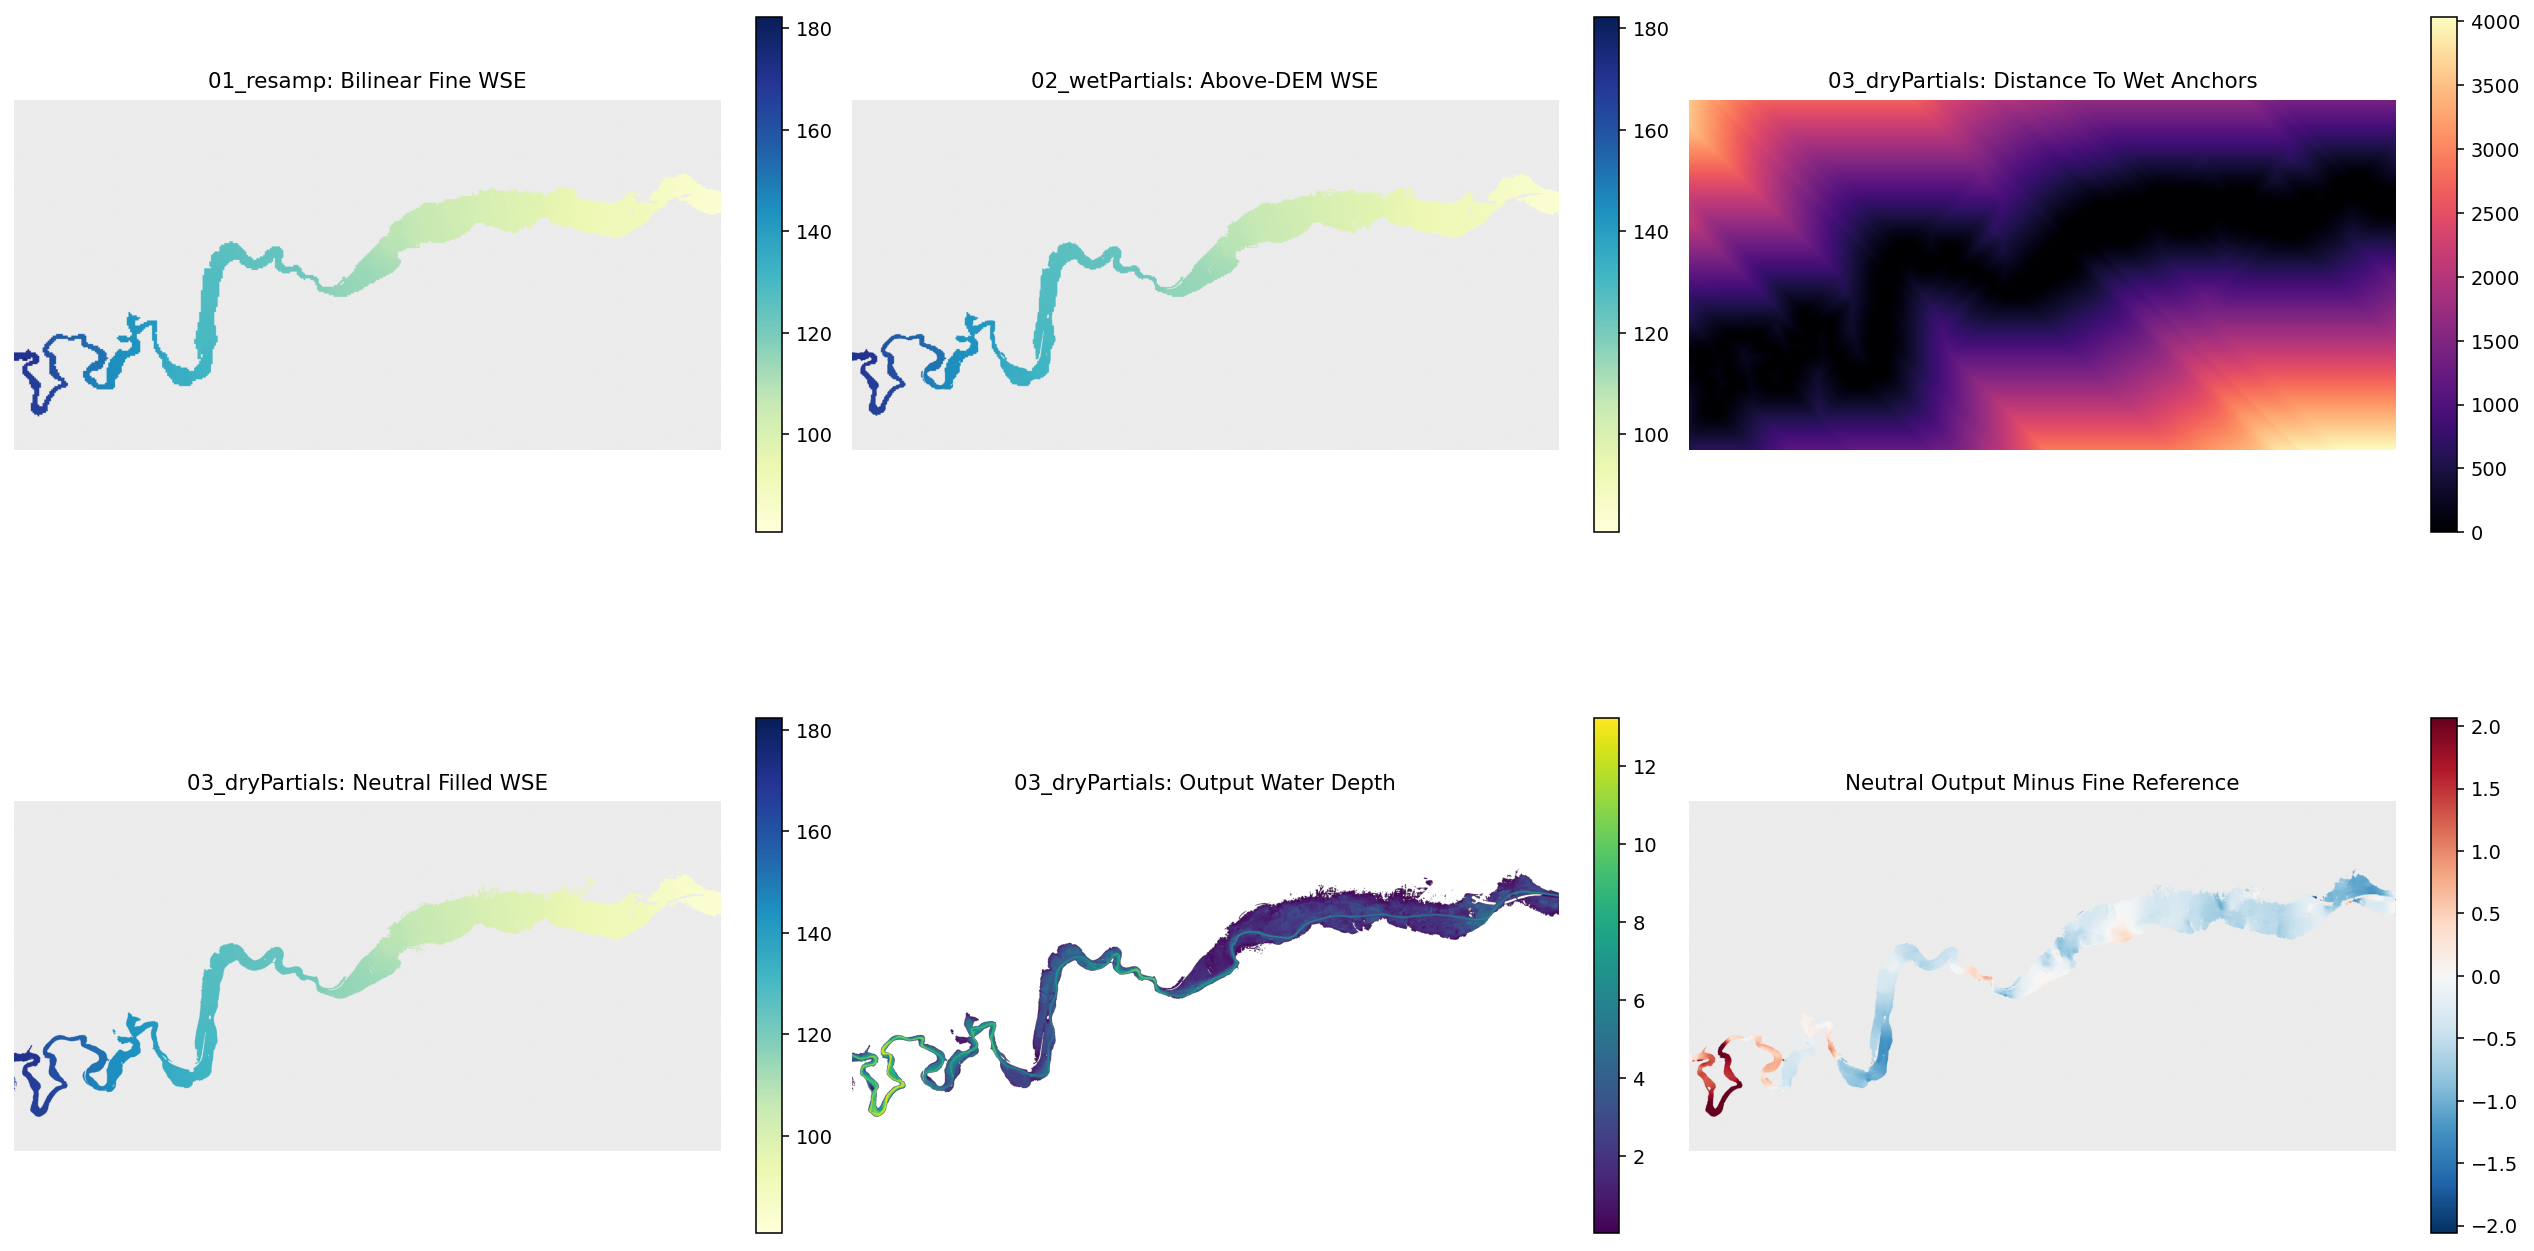

{'downscale': 8, 'pixel_size_m': 4.0, 'coarse_wet_cells': 6907, 'resampled_wet_cells': 442048, 'wet_partial_cells': 425253, 'neutral_output_cells': 449443, 'grown_cells': 24190, 'runtime_seconds': 0.463}


In [5]:
# Reuse the DEM and WSE color ramps so the plots remain visually comparable.
distance_cmap = plt.cm.magma.copy()
distance_cmap.set_bad("#ececec")

delta_cmap = plt.cm.RdBu_r.copy()
delta_cmap.set_bad("#ececec")

delta_limit = np.nanpercentile(np.abs(delta_to_ref), 98)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

im = axes[0, 0].imshow(wse_fine_01, cmap=wse_cmap, vmin=wse_vmin, vmax=wse_vmax)
axes[0, 0].set_title("01_resamp: Bilinear Fine WSE")
axes[0, 0].set_axis_off()
fig.colorbar(im, ax=axes[0, 0], shrink=0.75)

im = axes[0, 1].imshow(wse_fine_02, cmap=wse_cmap, vmin=wse_vmin, vmax=wse_vmax)
axes[0, 1].set_title("02_wetPartials: Above-DEM WSE")
axes[0, 1].set_axis_off()
fig.colorbar(im, ax=axes[0, 1], shrink=0.75)

im = axes[0, 2].imshow(distance_ar, cmap=distance_cmap)
axes[0, 2].set_title("03_dryPartials: Distance To Wet Anchors")
axes[0, 2].set_axis_off()
fig.colorbar(im, ax=axes[0, 2], shrink=0.75)

im = axes[1, 0].imshow(wse_fine_03, cmap=wse_cmap, vmin=wse_vmin, vmax=wse_vmax)
axes[1, 0].set_title("03_dryPartials: Neutral Filled WSE")
axes[1, 0].set_axis_off()
fig.colorbar(im, ax=axes[1, 0], shrink=0.75)

im = axes[1, 1].imshow(wsh_fine_03, cmap=plt.cm.viridis)
axes[1, 1].set_title("03_dryPartials: Output Water Depth")
axes[1, 1].set_axis_off()
fig.colorbar(im, ax=axes[1, 1], shrink=0.75)

im = axes[1, 2].imshow(delta_to_ref, cmap=delta_cmap, vmin=-delta_limit, vmax=delta_limit)
axes[1, 2].set_title("Neutral Output Minus Fine Reference")
axes[1, 2].set_axis_off()
fig.colorbar(im, ax=axes[1, 2], shrink=0.75)

plt.show()

print(meta_d)
